In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from funciones import detectar_digito

#np.set_printoptions(threshold=np.inf)

In [64]:
fs_a, audio_a = wavfile.read('tlfn-a.wav')
fs_b, audio_b = wavfile.read('tlfn-b.wav')

print(f'Audio a')
print(f'{fs_a} muestras por segundo')
print(f'{audio_a.shape[0]} muestras, {audio_a.shape[1]} canales')

print(f'Audio b')
print(f'{fs_b} muestras por segundo')
print(f'{audio_b.shape[0]} muestras, {audio_b.shape[1]} canales')

Audio a
44100 muestras por segundo
45000 muestras, 2 canales
Audio b
44100 muestras por segundo
195000 muestras, 2 canales


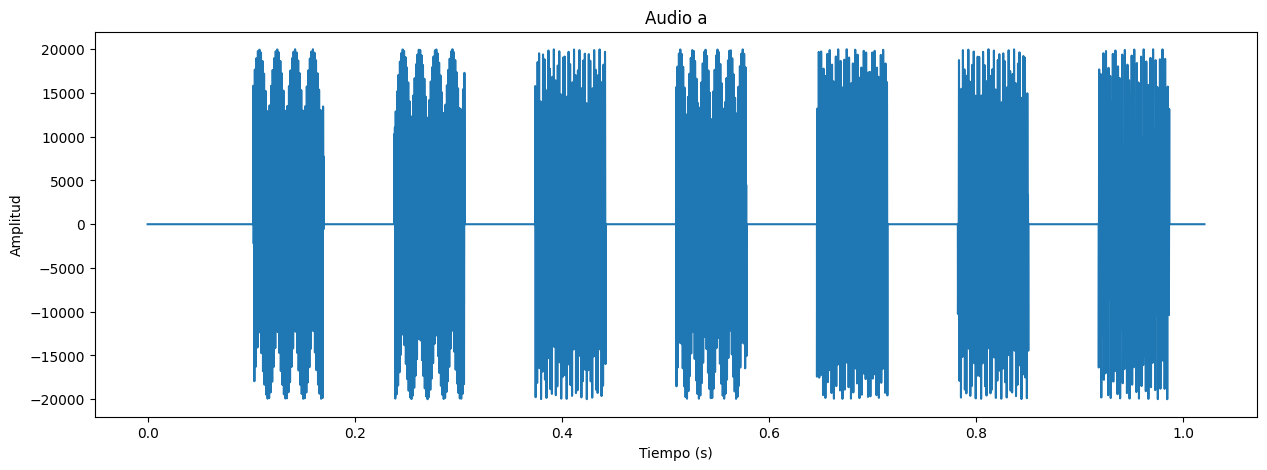

In [65]:
canal_a = audio_a[:,0]              # Me quedo con un canal
ta = np.arange(len(canal_a)) / fs_a

plt.figure(figsize=(15,5))
plt.plot(ta, canal_a)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title(f'Audio a')
plt.show()

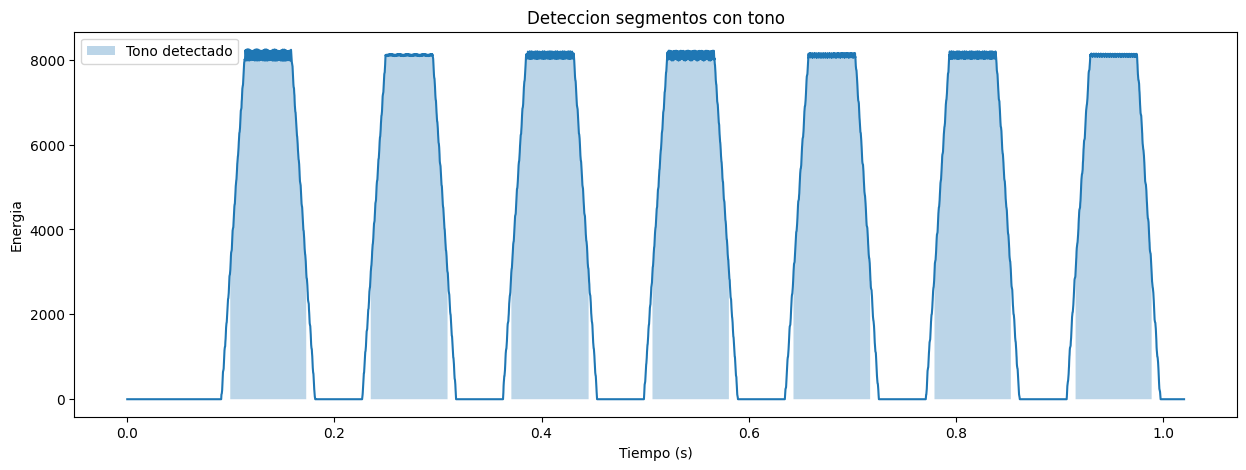

In [75]:
amplitud = np.abs(canal_a)

ventana = 1000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

umbral = 3000

hay_senal = energia > umbral 

plt.figure(figsize=(15,5))

plt.plot(ta, energia)
plt.fill_between(
    ta,
    0,
    energia,
    where=hay_senal,
    alpha=0.3,
    label='Tono detectado'
)
plt.xlabel(f'Tiempo (s)')
plt.ylabel(f'Energia')
plt.title(f'Deteccion segmentos con tono')
plt.legend()
plt.show()


In [67]:
cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

tiempos_inicio = inicios / fs_a
tiempos_final = finales / fs_a


print([f'Segmento {i+1}: [{inicio:.2f}s, {final:.2f}s]' for i, (inicio, final) in enumerate(zip(tiempos_inicio, tiempos_final))])

['Segmento 1: [0.10s, 0.17s]', 'Segmento 2: [0.24s, 0.31s]', 'Segmento 3: [0.37s, 0.45s]', 'Segmento 4: [0.51s, 0.58s]', 'Segmento 5: [0.64s, 0.72s]', 'Segmento 6: [0.78s, 0.85s]', 'Segmento 7: [0.92s, 0.99s]']


Las frecuencias detectadas son: [ 695.02472188 1335.53770087]


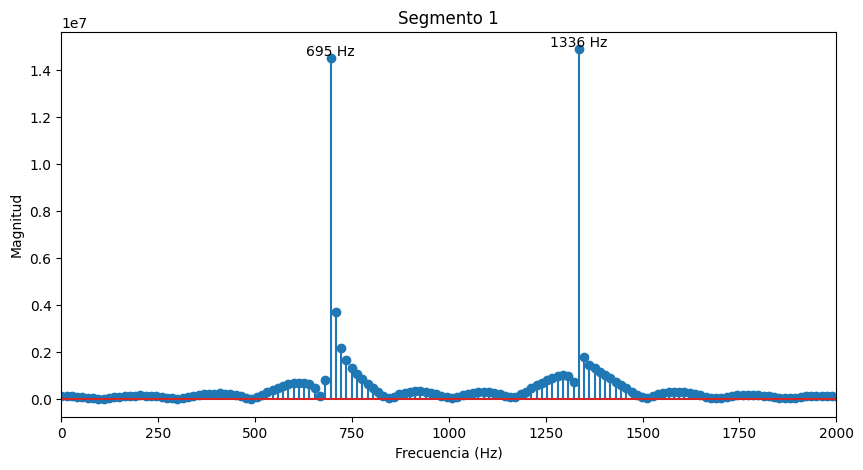

Las frecuencias detectadas son: [ 768.24572127 1482.5794621 ]


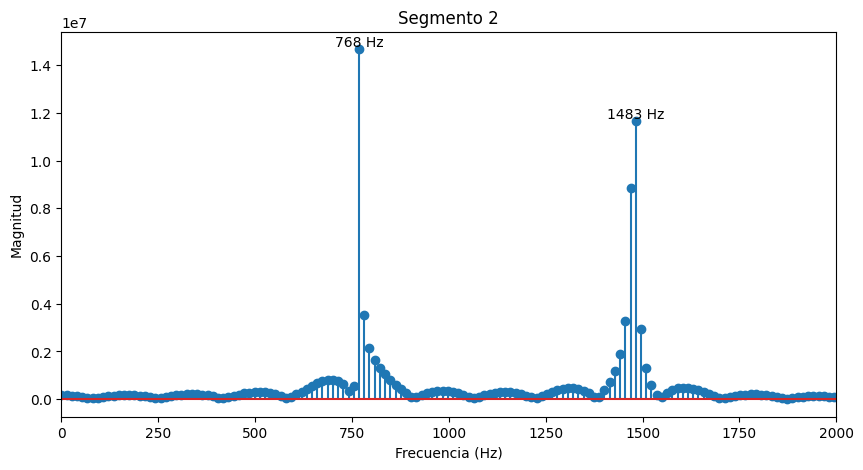

Las frecuencias detectadas son: [ 763.81039198 1340.01823154]


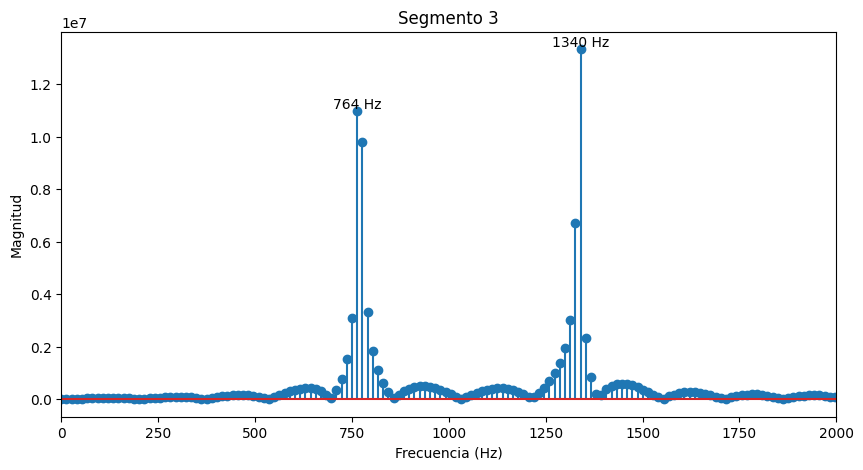

Las frecuencias detectadas son: [ 690.96774194 1476.77419355]


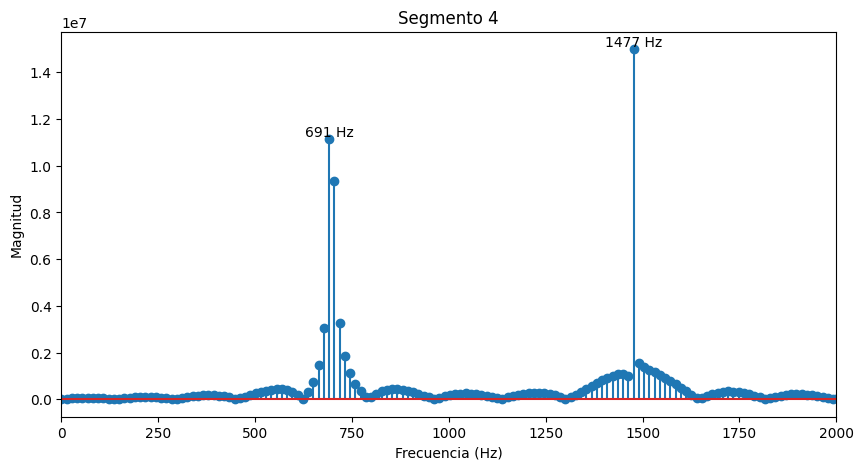

Las frecuencias detectadas son: [ 850.67360686 1336.77281078]


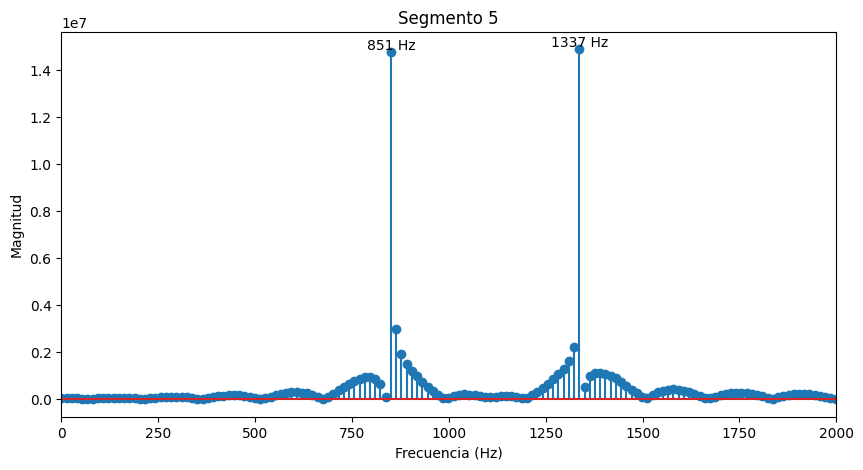

Las frecuencias detectadas son: [ 772.9704797  1342.52767528]


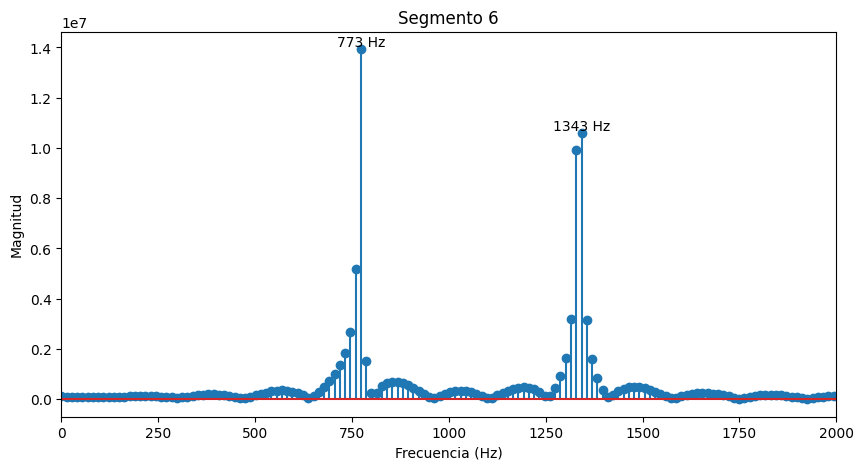

Las frecuencias detectadas son: [ 775.83333333 1211.38888889]


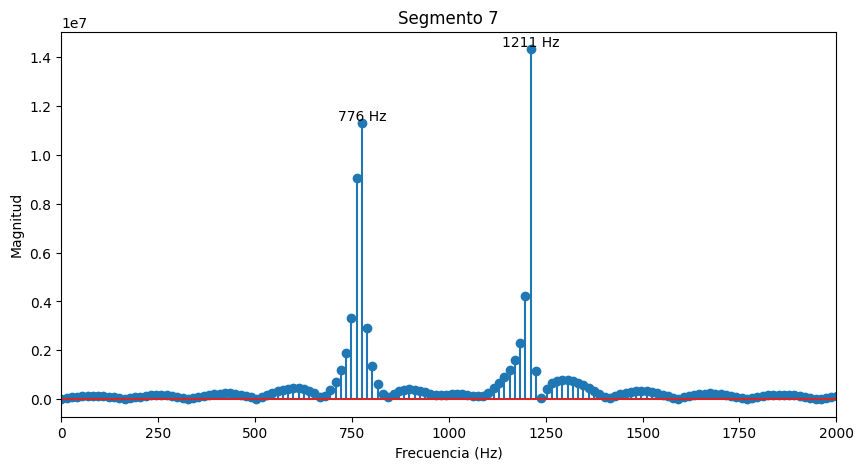

In [68]:
for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    segmento = canal_a[inicio:final]

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_a)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]
    magnitud = np.abs(transformada[:mitad])

    indices = np.argsort(magnitud)
    picos = np.sort(indices[-2:])
    freq_detectadas = frecuencias[picos]

    print(f'Las frecuencias detectadas son: {freq_detectadas}')

    plt.figure(figsize=(10,5))

    plt.stem(frecuencias, magnitud)
    
    for j in range(len(picos)):
        plt.text(freq_detectadas[j], magnitud[picos[j]], f'{freq_detectadas[j]:.0f} Hz', ha='center', va='bottom')

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title(f'Segmento {i+1}')
    plt.xlim(0, 2000)

    plt.show()

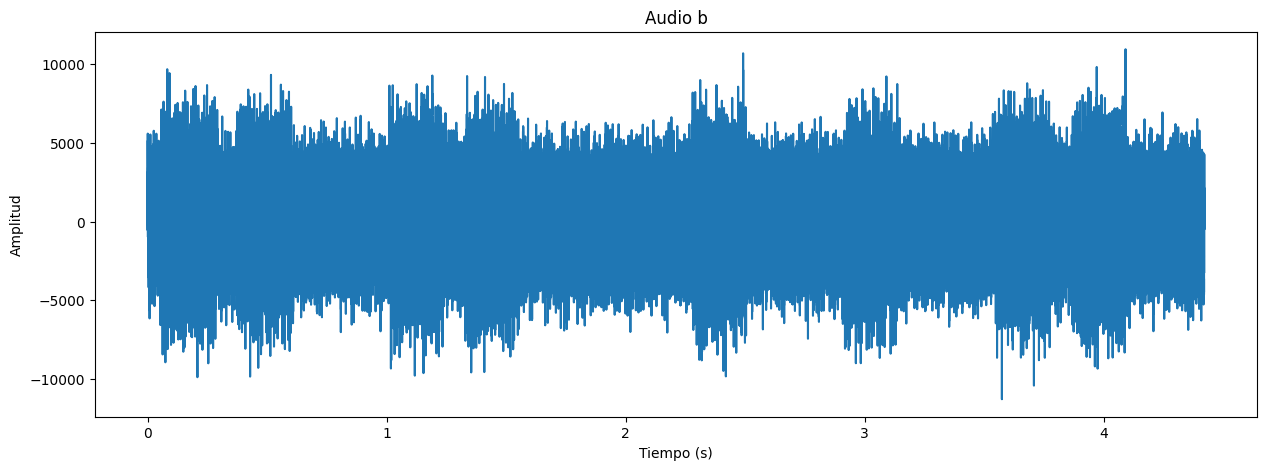

In [69]:
canal_b = audio_b[:,0]              # Me quedo con un canal
tb = np.arange(len(canal_b)) / fs_b

plt.figure(figsize=(15,5))
plt.plot(tb, canal_b)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Audio b')
plt.show()

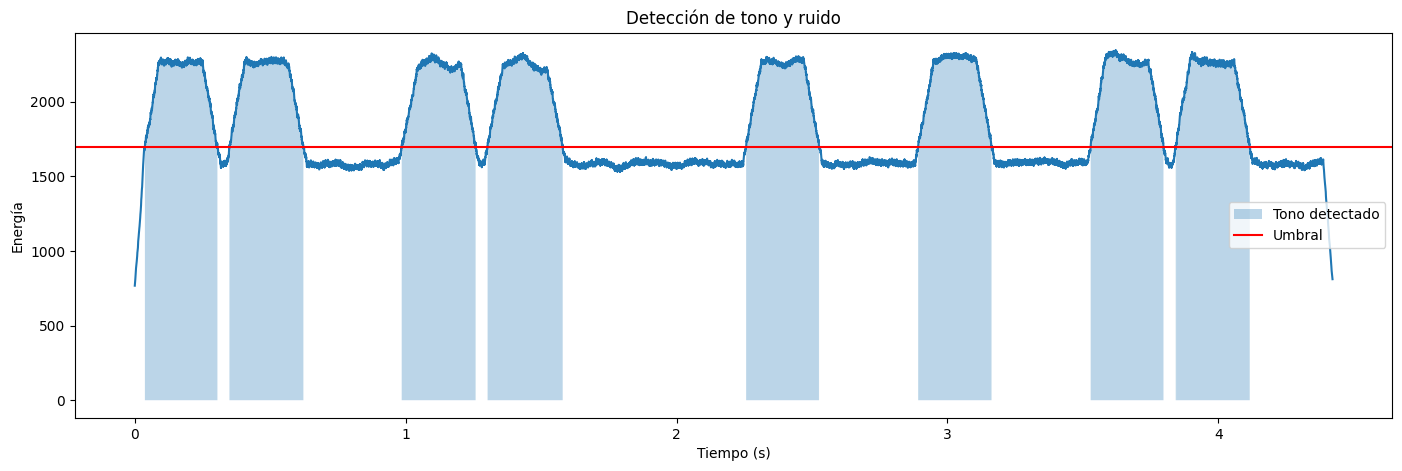

In [76]:
amplitud = np.abs(canal_b)

ventana = 3000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

umbral = 1700

hay_senal = energia > umbral 

plt.figure(figsize=(17,5))
plt.plot(tb, energia)
plt.fill_between(
    tb,
    0,
    energia,
    where=hay_senal,
    alpha=0.3,
    label='Tono detectado'
)
plt.axhline(umbral, color='red', label='Umbral')
plt.xlabel('Tiempo (s)')
plt.ylabel('Energía')
plt.title(f'Detección de tono y ruido')
plt.legend(loc='right')
plt.show()

In [71]:
cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

duracion_minima = 0.05   # segundos

inicios_filtrados = []
finales_filtrados = []

for inicio, final in zip(inicios, finales):

    duracion = (final - inicio) / fs_b

    if duracion > duracion_minima:

        inicios_filtrados.append(inicio)
        finales_filtrados.append(final)

inicios = np.array(inicios_filtrados)
finales = np.array(finales_filtrados)

tiempos_inicio = inicios / fs_a
tiempos_final = finales / fs_a

#print(f'Tiempos inicio: {tiempos_inicio}')
#print(f'Tiempos final: {tiempos_final}')

print([f'Segmento {i}: [{inicio:.2f}s, {final:.2f}s]' for i, (inicio, final) in enumerate(zip(tiempos_inicio, tiempos_final))])

['Segmento 0: [0.04s, 0.31s]', 'Segmento 1: [0.35s, 0.62s]', 'Segmento 2: [0.99s, 1.26s]', 'Segmento 3: [1.30s, 1.58s]', 'Segmento 4: [2.26s, 2.53s]', 'Segmento 5: [2.89s, 3.16s]', 'Segmento 6: [3.53s, 3.80s]', 'Segmento 7: [3.84s, 4.12s]']


Frecuencia baja: 852
Frecuencia alta: 1477
Dígito detectado: 9


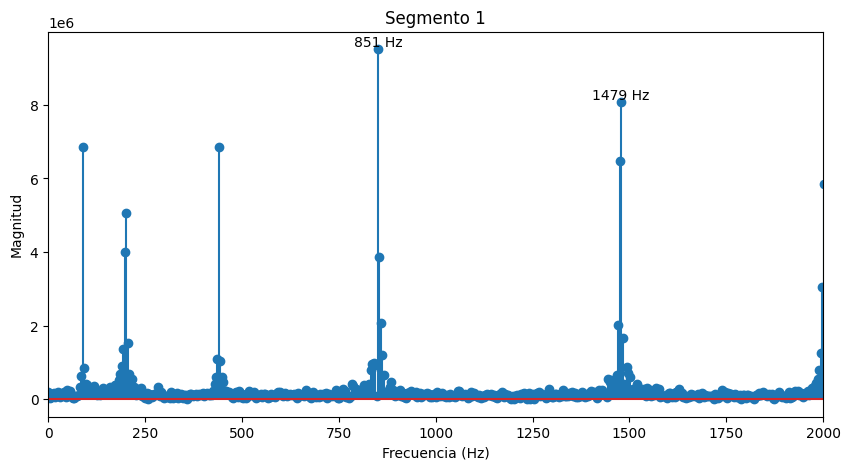

Frecuencia baja: 852
Frecuencia alta: 1209
Dígito detectado: 7


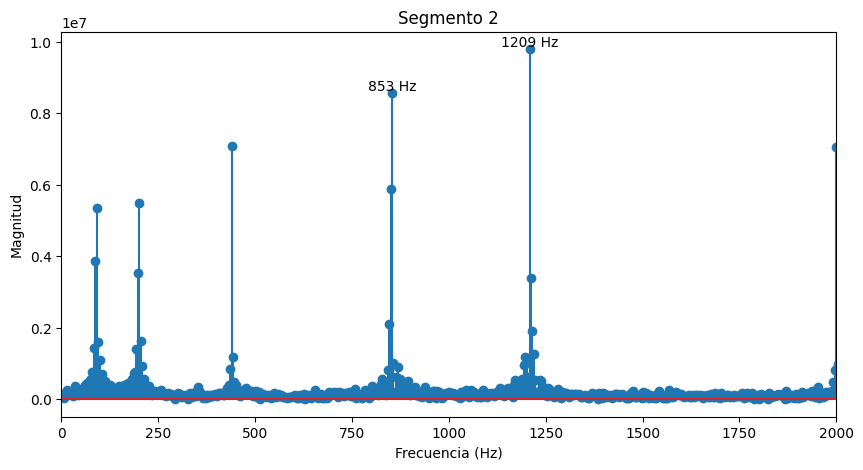

Frecuencia baja: 852
Frecuencia alta: 1209
Dígito detectado: 7


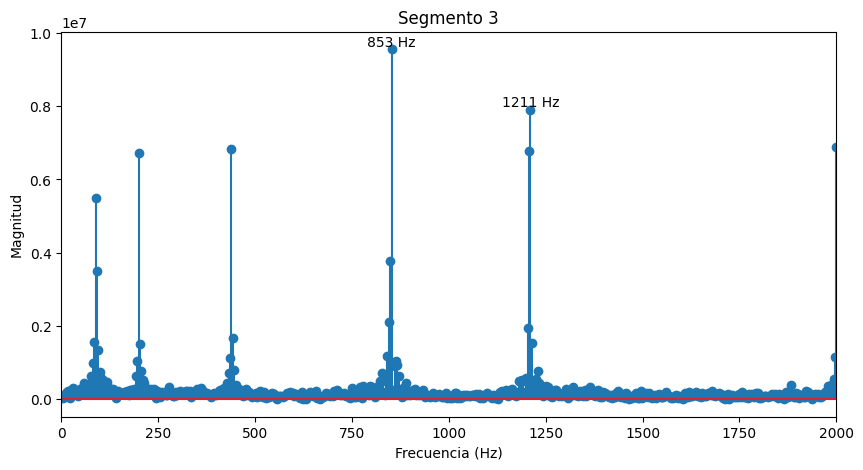

Frecuencia baja: 770
Frecuencia alta: 1477
Dígito detectado: 6


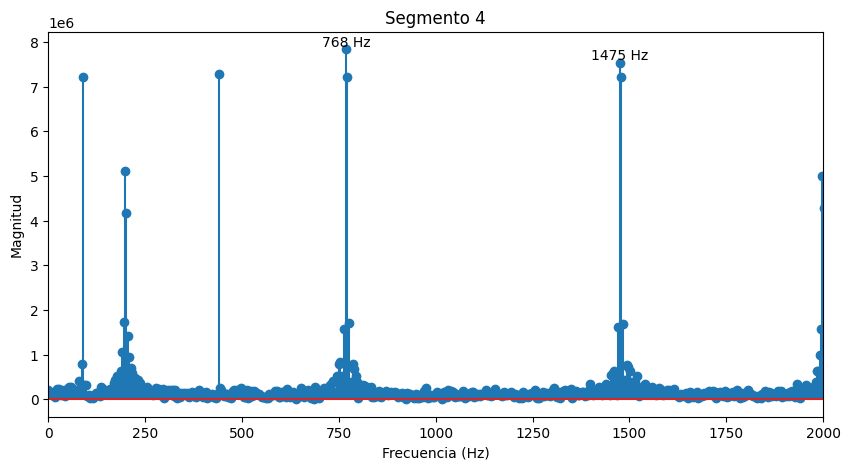

Frecuencia baja: 852
Frecuencia alta: 1336
Dígito detectado: 8


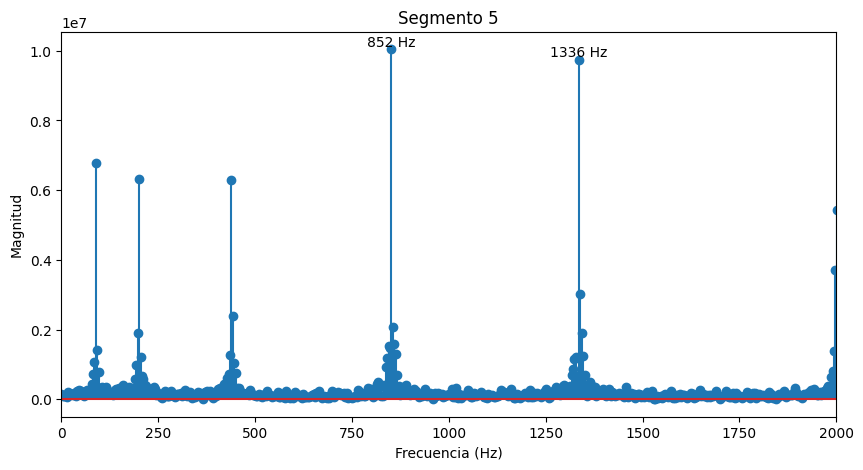

Frecuencia baja: 770
Frecuencia alta: 1209
Dígito detectado: 4


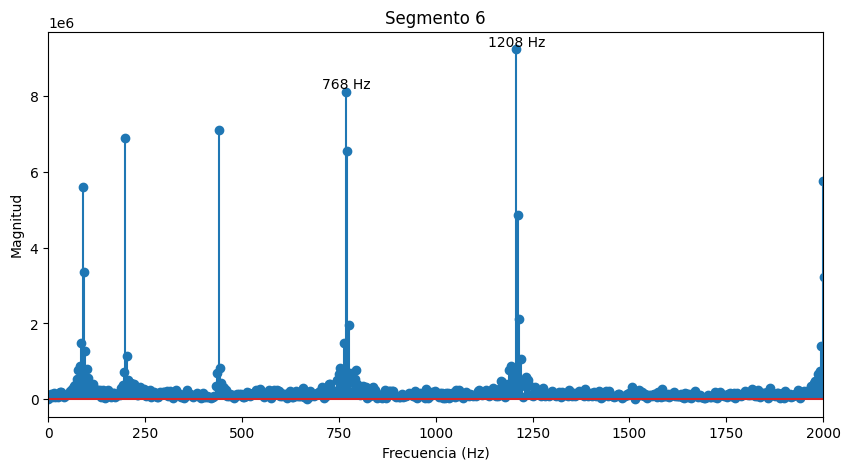

Frecuencia baja: 941
Frecuencia alta: 1336
Dígito detectado: 0


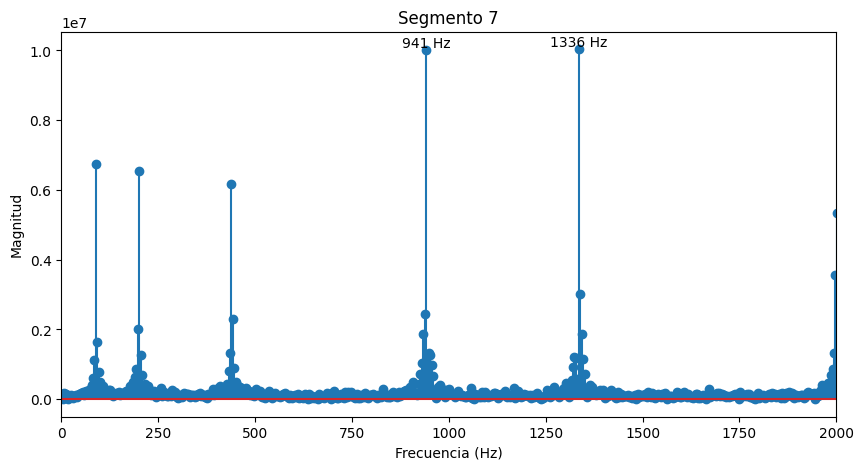

Frecuencia baja: 697
Frecuencia alta: 1477
Dígito detectado: 3


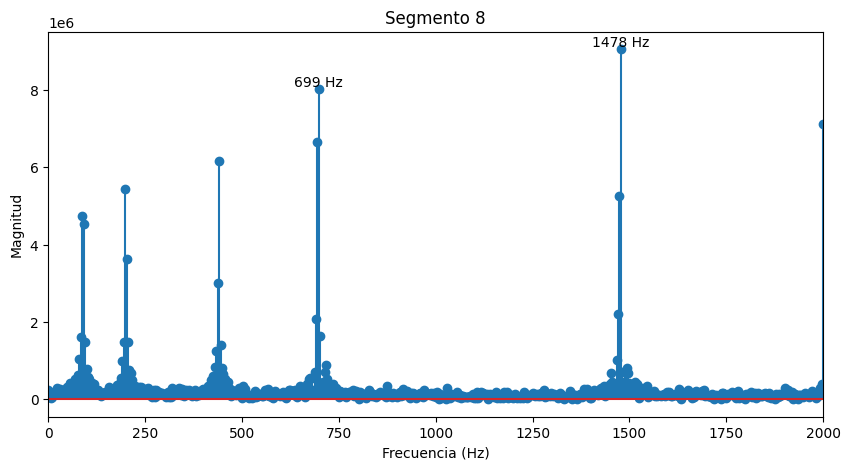

Número reconocido: 97768403


In [72]:
numero = ''

for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    segmento = canal_b[inicio:final]

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_b)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]
    magnitud = np.abs(transformada[:mitad])

    indices = np.argsort(magnitud)
    picos = np.sort(indices[-2:])
    freq_detectadas = frecuencias[picos]
    
    digito, fb, fa = detectar_digito(frecuencias, magnitud)

    print(f'Frecuencia baja: {fb}')
    print(f'Frecuencia alta: {fa}')
    print(f'Dígito detectado: {digito}')
    
    numero += digito
    
    plt.figure(figsize=(10,5))

    plt.stem(frecuencias, magnitud)
    
    
    for j in range(len(picos)):
        plt.text(freq_detectadas[j], magnitud[picos[j]]+2, f'{freq_detectadas[j]:.0f} Hz', ha='center', va='bottom')
    
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title(f'Segmento {i+1}')
    plt.xlim(0, 2000)

    plt.show()
    
print(f'Número reconocido: {numero}')